## Fasttext-признаки, обученные самостоятельно

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import nltk
import nltk.corpus
import nltk.tokenize
import string
import gensim
from string import punctuation
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.utils.data as data_utils
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [2]:
negative_file='C:\\Users\\Landi\\ИТМО\\2 сем\\NLP\\lab1\\negative.csv'
positive_file='C:\\Users\\Landi\\ИТМО\\2 сем\\NLP\\lab1\\positive.csv'

#считываем файл
negative_df = pd.read_csv(negative_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'], nrows=10000)
positive_df = pd.read_csv(positive_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'], nrows=10000)

sentiment = pd.concat([negative_df, positive_df])[['ttext', 'ttype']]
sentiment.loc[(sentiment.ttype < 0), ('ttype')] = 0
sentiment

,ttext,ttype
0,на работе был полный пиддес :| и так каждое за...,0
1,"Коллеги сидят рубятся в Urban terror, а я из-з...",0
2,@elina_4post как говорят обещаного три года жд...,0
3,"Желаю хорошего полёта и удачной посадки,я буду...",0
4,"Обновил за каким-то лешим surf, теперь не рабо...",0
...,...,...
9995,"Все равно, я бы чувствовала себя лучше, если б...",1
9996,-Я пошла вешаться...-Что?! Что случилось?-Проб...,1
9997,"Идеальный перерыв с любимой Катюхой, пиано мас...",1
9998,Удахгүй дүн гарахаар мэдээлэл хийнээ :)) http:...,1


In [3]:
#разделяем датасет на train и test
X=sentiment['ttext'].values.tolist()
y=sentiment['ttype'].values.tolist()

In [4]:
#разбиваем на токены
punctuations = list(punctuation)
punkt = ['``','...',"''",'«','»','…','”','”','“','-','–','..']
punctuations.extend(punkt)

def tokenize(text):
    text_token = nltk.word_tokenize(text)
    text_word=[x.lower() for x in text_token if x not in punctuations]
    return text_word


In [5]:
X_token = [tokenize(t) for t in X]

In [6]:
from gensim.models import FastText
ft_model = FastText(sentences=X_token, vector_size=300, window=5, min_count=1, workers=4, sg=0, min_n=2,  max_n=6)

In [8]:
ft_model.build_vocab(X_token)
ft_model.train(X_token, total_examples=ft_model.corpus_count, epochs=300, report_delay=1)
ft_model.init_sims(replace=True)

C:\Users\Landi\AppData\Local\Temp\ipykernel_2064\3237287731.py:3: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  ft_model.init_sims(replace=True)


In [9]:
vector =ft_model.wv['работа']
vector

array([-1.17921986e-01,  6.01464361e-02,  5.23297675e-02,  2.52039148e-03,
       -5.63022904e-02,  6.56358956e-04, -7.22353458e-02, -2.60848850e-02,
        4.82649691e-02,  2.21780296e-02,  4.13237549e-02, -5.56723066e-02,
        3.38835292e-03,  8.66838545e-02,  6.05826601e-02,  1.43742806e-03,
       -3.74518409e-02, -7.25471228e-03,  1.85806118e-02, -4.20520157e-02,
       -8.93344264e-03, -2.98482850e-02, -3.44063602e-02,  6.89219758e-02,
        4.68240120e-03,  2.37023970e-03, -8.33003148e-02, -6.58625737e-02,
        1.19995074e-02, -2.75584199e-02,  4.29154001e-02, -7.50682727e-02,
        2.13231868e-03,  9.63290185e-02, -1.04084678e-01, -9.36160330e-03,
        6.09084219e-02, -2.84128487e-02, -1.84507295e-02,  4.36621197e-02,
       -7.24476278e-02, -4.04439420e-02, -7.23479688e-02,  2.01467965e-02,
        6.20837137e-02,  3.33760418e-02,  2.02298686e-02, -5.33026531e-02,
       -5.56117855e-02,  1.76501255e-02,  7.27972388e-02, -8.32010433e-03,
        2.29315087e-02, -

In [10]:
def word_averaging(model, words):
    all_words, mean = set(), []

    for word in words:
        mean.append(ft_model.wv[word])
        all_words.add(word)

    if not mean:
        #logging.warning("cannot compute similarity with no input %s", words)
        # FIXME: remove these examples in pre-processing
        return np.zeros(model.vector_size)

    mean = gensim.matutils.unitvec(np.array(mean).mean(axis=0)).astype(np.float32)
    return mean

In [11]:
def  word_averaging_list(model, text_list):
    return np.vstack([word_averaging(model, comment_text) for comment_text in text_list ])

In [13]:
word_vectors = ft_model.wv
X = word_averaging_list(ft_model, X_token)
X.shape
y=sentiment['ttype'].values.tolist()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [15]:
# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
def plot_confusion(model_name, y_pred, y_test):
   
    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    
    # Подписи классов
    labels = ["Отрицательный", "Положительный"]
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=labels,
                yticklabels=labels)
    plt.xlabel("Предсказанные метки")
    plt.ylabel("Истинные метки")
    plt.title(f"Матрица ошибок ({model_name})")
    plt.show()

In [17]:
# Создание и обучение модели
svc = SVC(random_state=42, kernel='rbf')
svc.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False



Classification report:

               precision    recall  f1-score   support

           0       0.72      0.73      0.73      2990
           1       0.73      0.72      0.72      3010

    accuracy                           0.73      6000
   macro avg       0.73      0.73      0.73      6000
weighted avg       0.73      0.73      0.73      6000



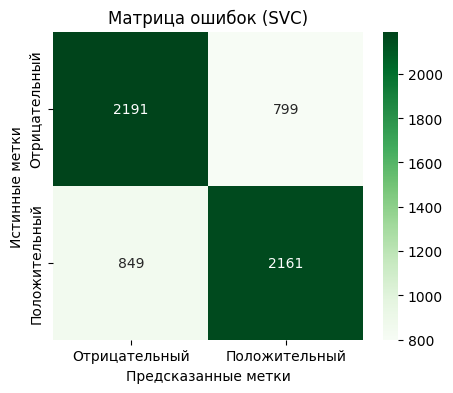

In [18]:
# Предсказания
y_pred_svc = svc.predict(X_test_scaled)

print("\nClassification report:\n\n", classification_report(y_test, y_pred_svc))
plot_confusion("SVC", y_pred_svc, y_test)